In [3]:
# import the libraries
import numpy as np
import pandas as pd


In [4]:
# loading the dataset
data = pd.read_csv("C:\\Users\KAVITA\Downloads\loan_sanction_test.csv")


In [5]:
# Display the first few rows of the dataset to understand its structure.

data.head(7)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban
5,LP001054,Male,Yes,0,Not Graduate,Yes,2165,3422,152.0,360.0,1.0,Urban
6,LP001055,Female,No,1,Not Graduate,No,2226,0,59.0,360.0,1.0,Semiurban


In [6]:

# Check for missing values and handle them if necessary.

data.isna().sum()

Loan_ID               0
Gender               11
Married               0
Dependents           10
Education             0
Self_Employed        23
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            5
Loan_Amount_Term      6
Credit_History       29
Property_Area         0
dtype: int64

In [7]:
# to know about the short summary of entire dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            367 non-null    object 
 1   Gender             356 non-null    object 
 2   Married            367 non-null    object 
 3   Dependents         357 non-null    object 
 4   Education          367 non-null    object 
 5   Self_Employed      344 non-null    object 
 6   ApplicantIncome    367 non-null    int64  
 7   CoapplicantIncome  367 non-null    int64  
 8   LoanAmount         362 non-null    float64
 9   Loan_Amount_Term   361 non-null    float64
 10  Credit_History     338 non-null    float64
 11  Property_Area      367 non-null    object 
dtypes: float64(3), int64(2), object(7)
memory usage: 34.5+ KB


In [8]:
data['Gender'].mode()[0]

'Male'

In [9]:
# Check for missing values and handle them if necessary. 

In [10]:
data['Gender'] = data['Gender'].fillna(value=data['Gender'].mode()[0])


In [11]:
categorical_cols = data.select_dtypes(exclude="number")[['Dependents', 'Self_Employed']].columns.tolist()
categorical_cols


['Dependents', 'Self_Employed']

In [12]:
 data.select_dtypes(exclude="number").isna().sum()

Loan_ID           0
Gender            0
Married           0
Dependents       10
Education         0
Self_Employed    23
Property_Area     0
dtype: int64

In [13]:
for col in categorical_cols:
    data[col] = data[col].fillna(value=data[col].mode()[0])
    

In [14]:
 data.select_dtypes(exclude="number").isna().sum()

Loan_ID          0
Gender           0
Married          0
Dependents       0
Education        0
Self_Employed    0
Property_Area    0
dtype: int64

In [15]:
numerical_cols = data.select_dtypes(include="number").columns.tolist()
numerical_cols

['ApplicantIncome',
 'CoapplicantIncome',
 'LoanAmount',
 'Loan_Amount_Term',
 'Credit_History']

In [16]:
# to check the null values in numerical cols
data.select_dtypes(include="number").isna().sum()

ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            5
Loan_Amount_Term      6
Credit_History       29
dtype: int64

In [17]:
for col in numerical_cols:
    data[col] = data[col].fillna(value=data[col].median())
    

In [18]:
data.isna().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
dtype: int64

this data is cleaned successfully! -> null values are totally eliminated !

now, we can move ahead with next step of analysis!

##### 3. Summarize basic statistics (mean, median, standard deviation, etc.) for the numeric columns

In [19]:
data.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,367.000000,367.000000,367.000000,367.000000,367.000000
mean,4805.599455,1569.577657,135.980926,342.822888,0.839237
std,4910.685399,2334.232099,60.959739,64.658402,0.367814
min,0.000000,0.000000,28.000000,6.000000,0.000000
25%,2864.000000,0.000000,101.000000,360.000000,1.000000
50%,3786.000000,1025.000000,125.000000,360.000000,1.000000
75%,5060.000000,2430.500000,157.500000,360.000000,1.000000
max,72529.000000,24000.000000,550.000000,480.000000,1.000000


## Analysis

#### 2.1 Univariate Analysis

###### 1. Histograms: Plot the frequency distribution of key numeric variables

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns


In [21]:
numerical_cols

['ApplicantIncome',
 'CoapplicantIncome',
 'LoanAmount',
 'Loan_Amount_Term',
 'Credit_History']

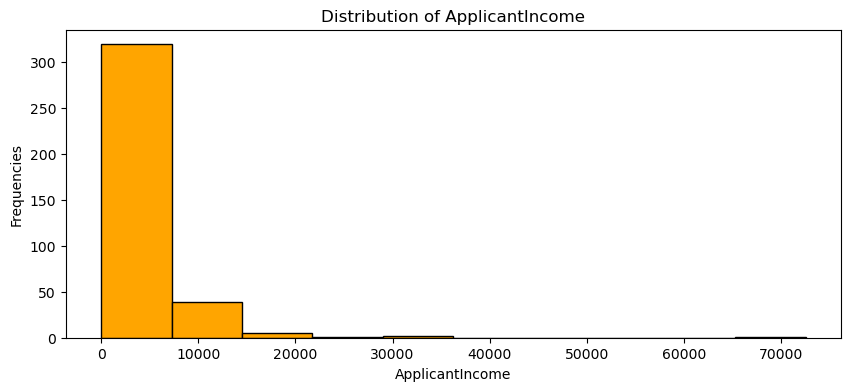

In [22]:
# histogram
plt.figure(figsize=(10,4))
plt.hist(data['ApplicantIncome'], color='orange', edgecolor="black")
plt.xlabel("ApplicantIncome")
plt.ylabel("Frequencies")
plt.title("Distribution of ApplicantIncome")
plt.show()

#### insight:

the chart says that the most of people who applied for the loan, have incomes in between 10 to 10000 Rs.

and, rest cases are rarest or, outliers (exceptional cases).


In [23]:
from scipy.stats import skew
skew(data['ApplicantIncome'])

np.float64(8.40683417612701)

In [24]:
# for col in numerical_cols:

#     plt.figure(figsize=(10,4))
#     plt.hist(data[col], color='orange', edgecolor="black")
#     plt.xlabel(col)
#     plt.ylabel("Frequencies")
#     plt.title(f"Distribution of {col}")
#     plt.show()
#     print("-"*120)

##### insight of every chart:




##### 2. Box Plots: Identify potential outliers and visualize the spread of data

Text(0.5, 1.0, 'Spread of Incomes of People')

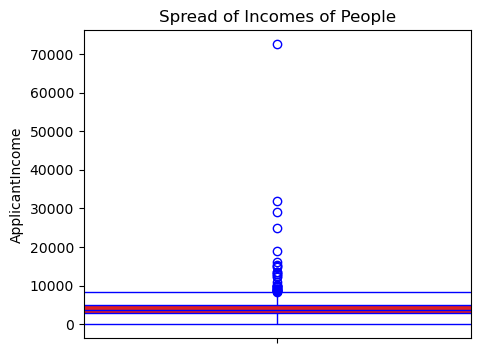

In [25]:
plt.figure(figsize=(5, 4))
sns.boxplot(data['ApplicantIncome'], color="red", gap=40, linecolor="blue", linewidth=1)
plt.title("Spread of Incomes of People")

##### Insight:

there is only 1 person, with income above Rs. 72,000 who applied for the Loan, and most of the people who applied for the loan are presnet in the bracket of 5000 to 12,000

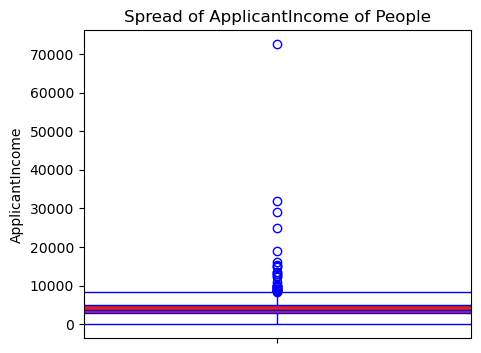

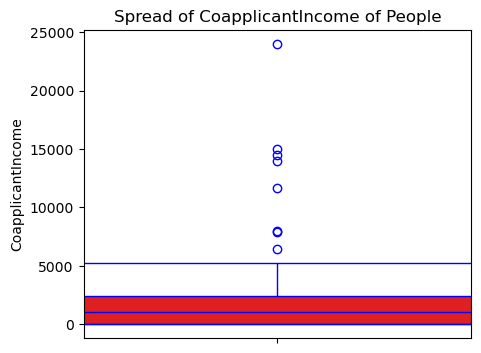

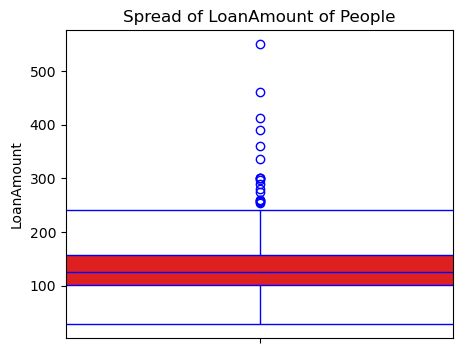

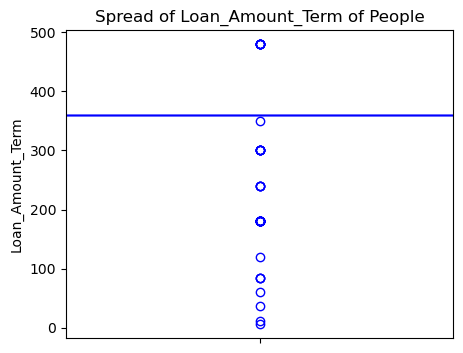

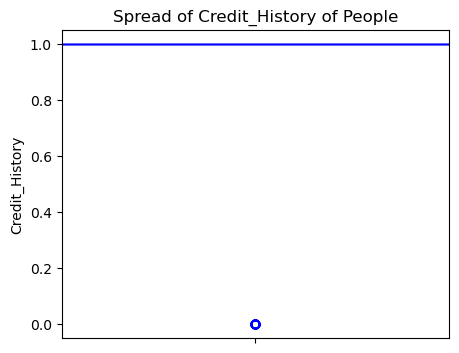

In [26]:
for col in numerical_cols:
    plt.figure(figsize=(5, 4))
    sns.boxplot(data[col], color="red", gap=40, linecolor="blue", linewidth=1)
    plt.title(f"Spread of {col} of People")

    

##### insight:
***ApplicantIncome → Wide spread with clear outliers; higher incomes drive larger loan amounts.***

***CoapplicantIncome → More variation, but less direct influence compared to applicant income.***

***LoanAmount → Shows strong variability with notable outliers, reflecting diverse borrowing needs.***

***Loan_Amount_Term → Mostly clustered around standard terms (e.g., 360 months), limited variation.****

***Credit_History → Clear split: applicants with good credit histories align with higher loan approvals, while poor credit restricts loan size regardless of income.***

***Core takeaway: Income explains loan demand variability, but credit history remains the decisive factor for loan approval.***



distribution  -> frequencies!

x-axis -> data/values
y-axis -> counts

numericals -> histogram -> continuous values!
categorical -> bar charts!


##### 3. Bar Charts: Visualize the frequency distribution of categorical variables

In [27]:
categorical_cols = data.select_dtypes(include="object").columns.tolist()
categorical_cols

['Loan_ID',
 'Gender',
 'Married',
 'Dependents',
 'Education',
 'Self_Employed',
 'Property_Area']

In [28]:
result = data.groupby("Gender").agg(Counts=("Loan_ID", "count")).reset_index()
# result

result['totals'] = result.apply(lambda x: x.iloc[1], axis=1).sum()

result['pct_contbr'] = result.apply(lambda x: round((x[1]/x[2]), 2)*100, axis=1)

result

C:\Users\KAVITA\AppData\Local\Temp\ipykernel_3572\2838038022.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  result['pct_contbr'] = result.apply(lambda x: round((x[1]/x[2]), 2)*100, axis=1)


,Gender,Counts,totals,pct_contbr
0,Female,70,367,19.0
1,Male,297,367,81.0


[Text(0, 0, '70'), Text(0, 0, '297')]

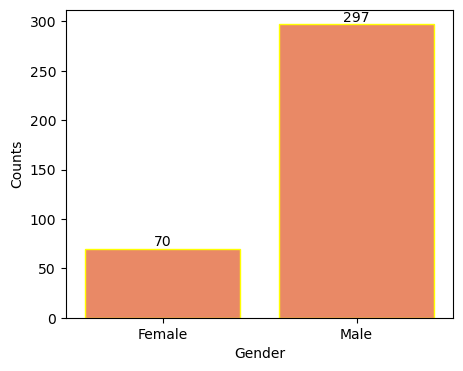

In [29]:
plt.figure(figsize=(5, 4))
ax = sns.barplot(x=result['Gender'], y=result['Counts'], edgecolor="yellow", color="coral" )

ax.bar_label(ax.containers[0]) #


#### insight:

The people who applied for the loan are mostly 'Males' with number around 297, which makes ***around 81%*** of overall applications in loans.

In [30]:
categorical_cols.remove("Loan_ID")

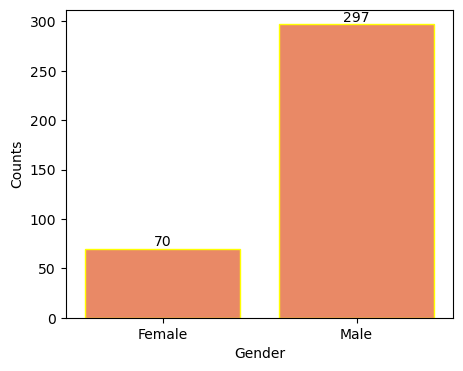

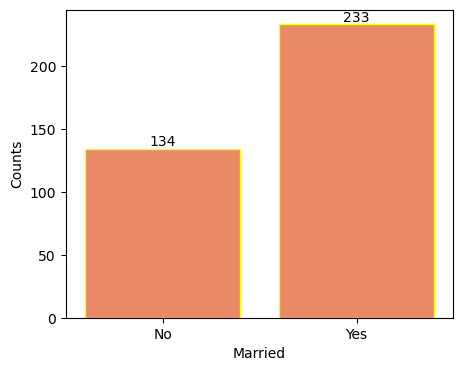

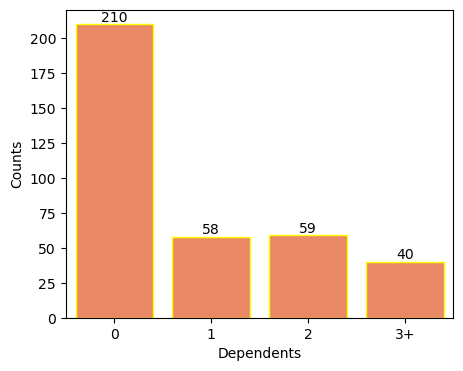

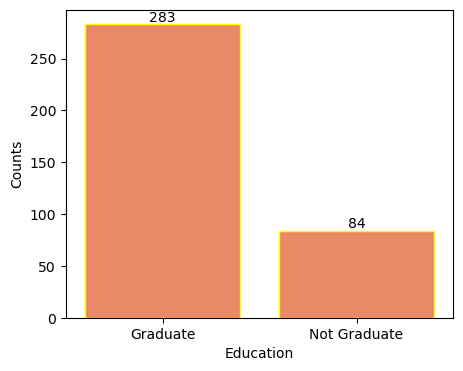

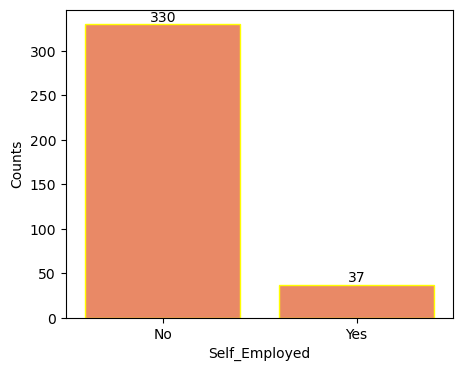

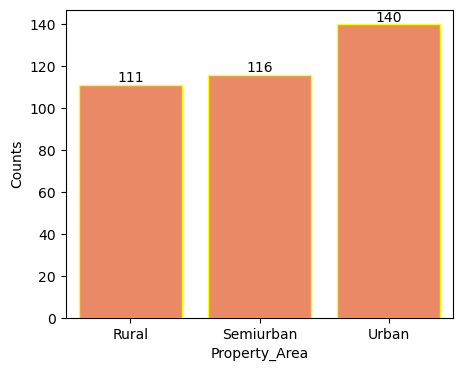

In [31]:
for col in categorical_cols:
    result = data.groupby(col).agg(Counts=("Loan_ID", "count")).reset_index()

    result["totals"] = result["Counts"].sum()

    result["pct_contrib"] = result.apply(lambda x: round((x["Counts"]/result["Counts"].sum()), 2)*100, axis=1)

    # print(result)
    
    plt.figure(figsize=(5, 4))
    ax = sns.barplot(x=result[col], y=result['Counts'], edgecolor="yellow", color="coral" )

    ax.bar_label(ax.containers[0]) #


In [ ]:
-

#### 4. Pie Charts: Represent the composition of categorical variables

In [114]:
result = data.groupby("Gender").size().reset_index().rename(columns={0:'Counts'})
result

,Gender,Counts
0,Female,70
1,Male,297


([<matplotlib.patches.Wedge at 0x1fe77ebca50>,
 [Text(0.9083571489611347, 0.6203928512895671, 'Female'),
  Text(-0.9083571317029622, -0.6203928765583689, 'Male')],
 [Text(0.49546753579698255, 0.3383961007034002, '19.1%'),
  Text(-0.49546752638343383, -0.338396114486383, '80.9%')])

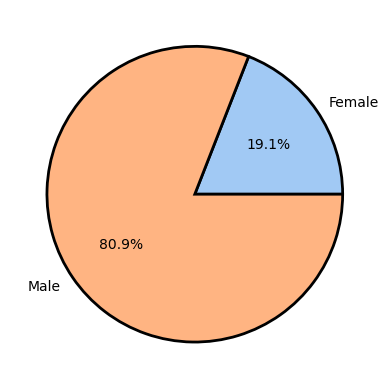

In [128]:
sns.set_palette("pastel")

plt.pie(x=result['Counts'], labels=result['Gender'], autopct="%1.1f%%",
       
       # --- Custom Border/Edge Settings ---
    wedgeprops={"edgecolor": "black", 'linewidth': 2, 'antialiased': True}   )


***Male dominance → Males form 80.9% of applicants, showing a strong skew in loan applications.***

***Female participation → Females account for only 19.1%, highlighting under‑representation in loan demand.***

***Business implication → Financial institutions could design outreach programs to encourage more female applicants, especially in semiurban and urban areas where participation is emerging.***

***Core takeaway: Loan applications are heavily male‑driven, with scope to expand female inclusion in financial services.***

In [32]:
data.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area'],
      dtype='object')

In [33]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            367 non-null    object 
 1   Gender             367 non-null    object 
 2   Married            367 non-null    object 
 3   Dependents         367 non-null    object 
 4   Education          367 non-null    object 
 5   Self_Employed      367 non-null    object 
 6   ApplicantIncome    367 non-null    int64  
 7   CoapplicantIncome  367 non-null    int64  
 8   LoanAmount         367 non-null    float64
 9   Loan_Amount_Term   367 non-null    float64
 10  Credit_History     367 non-null    float64
 11  Property_Area      367 non-null    object 
dtypes: float64(3), int64(2), object(7)
memory usage: 34.5+ KB


# ***2.2 Bivariate Analysis***
  


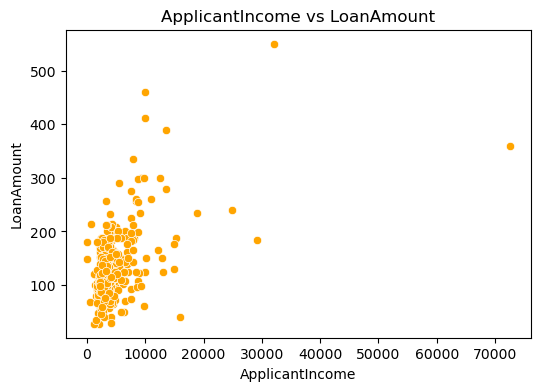

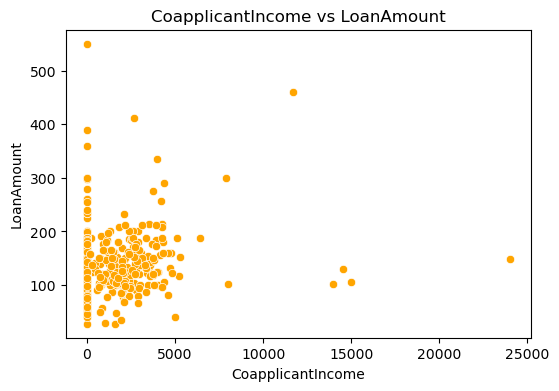

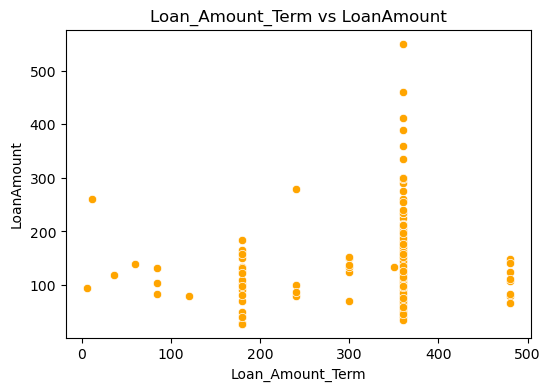

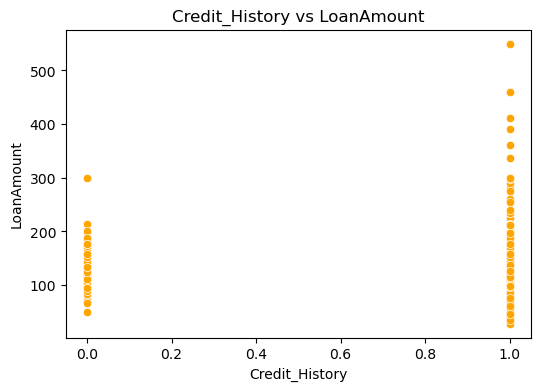

In [39]:
# Create scatter plots to explore relationships between pairs of numeric variables.   
numeric_cols = ['ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term','Credit_History']

# create scatter plots
for col in numeric_cols:
    if col != 'LoanAmount': 
        plt.figure(figsize=(6,4))
        sns.scatterplot(x=data[col], y=data['LoanAmount'], color = 'orange')
        plt.title(f"{col} vs LoanAmount")
        plt.xlabel(col)
        plt.ylabel("LoanAmount")
        plt.show()

<Figure size 1500x700 with 0 Axes>

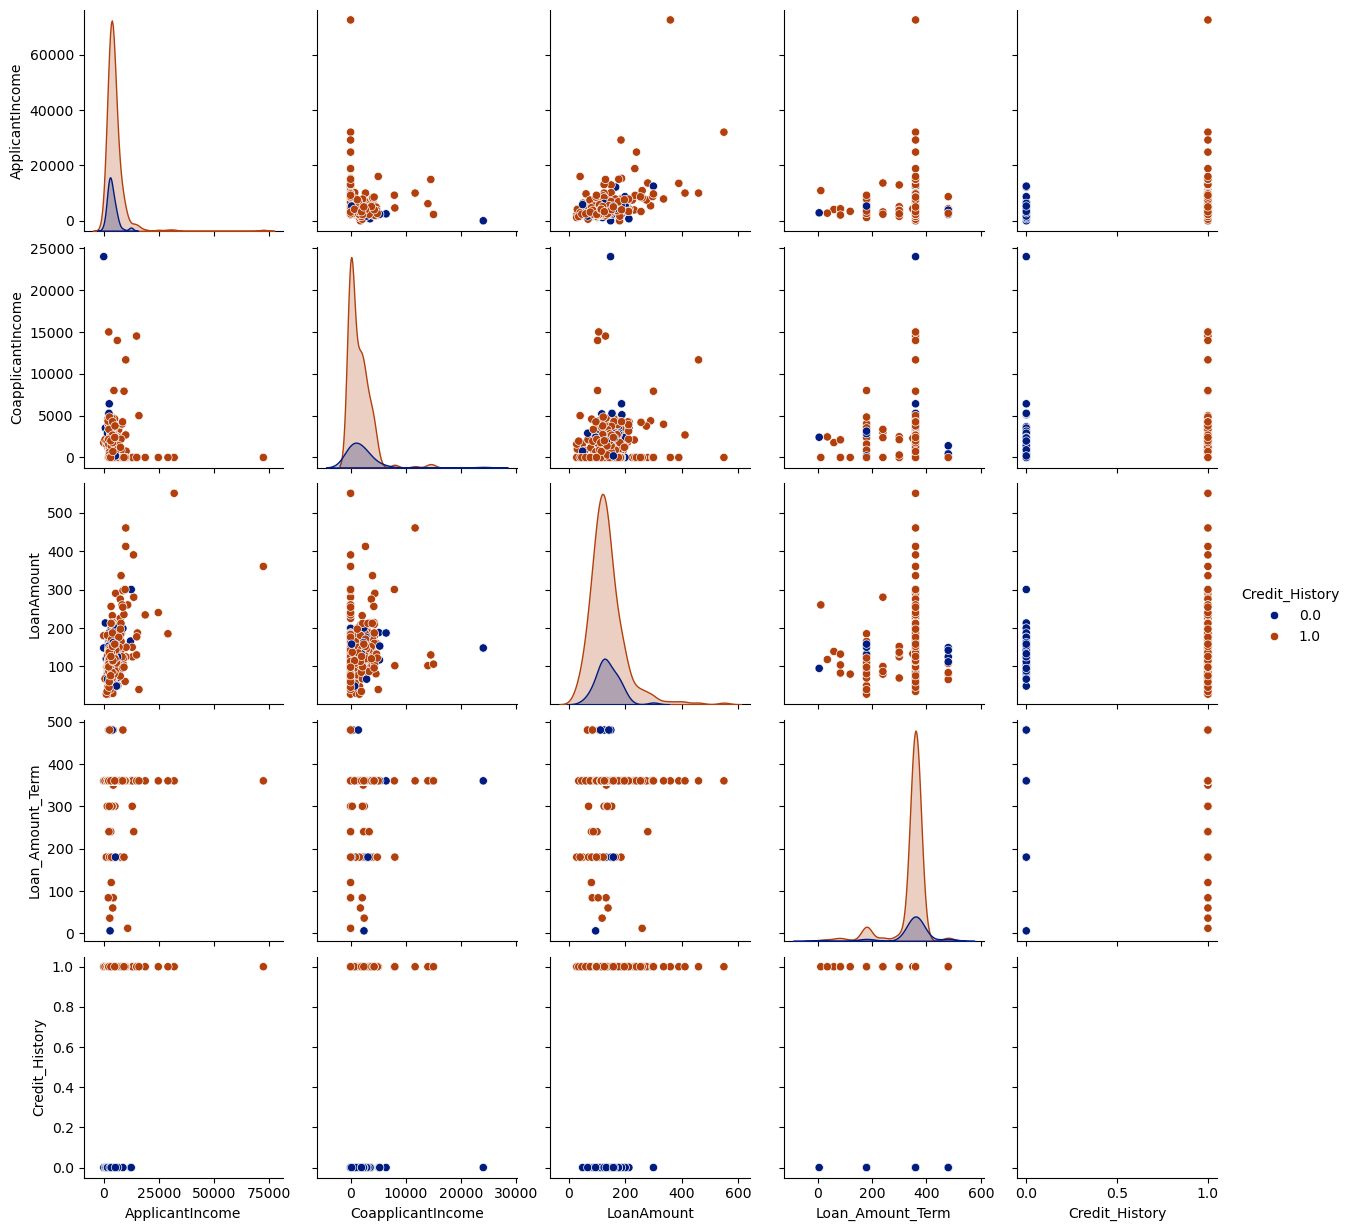

In [54]:
# Use pair plots (scatter matrix) to visualize interactions between multiple numeric variables simultaneously.   
plt.figure(figsize = (15,7))
sns.pairplot(data, vars=['ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term','Credit_History'],hue='Credit_History',palette='dark')
plt.show()

***Applicant income drives loan size → Higher incomes are linked with larger loan amounts.***

***Coapplicant income adds support → Secondary income helps but is less influential.***

***Credit history dominates → Good credit (1.0) applicants consistently secure bigger loans; poor credit (0.0) limits approvals regardless of income.***

***Loan term is stable → Most loans cluster around standard terms, showing little variation.***

***Core takeaway: Income influences loan demand, but credit history is the decisive factor for approval.***

In [57]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            367 non-null    object 
 1   Gender             367 non-null    object 
 2   Married            367 non-null    object 
 3   Dependents         367 non-null    object 
 4   Education          367 non-null    object 
 5   Self_Employed      367 non-null    object 
 6   ApplicantIncome    367 non-null    int64  
 7   CoapplicantIncome  367 non-null    int64  
 8   LoanAmount         367 non-null    float64
 9   Loan_Amount_Term   367 non-null    float64
 10  Credit_History     367 non-null    float64
 11  Property_Area      367 non-null    object 
dtypes: float64(3), int64(2), object(7)
memory usage: 34.5+ KB


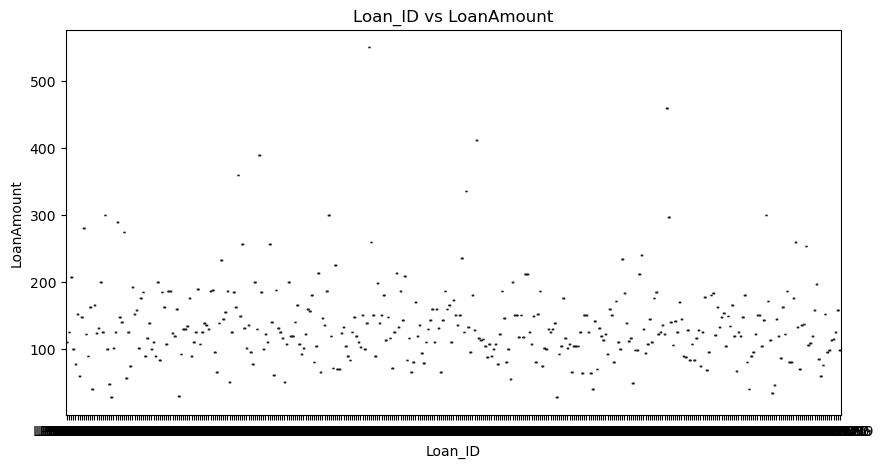

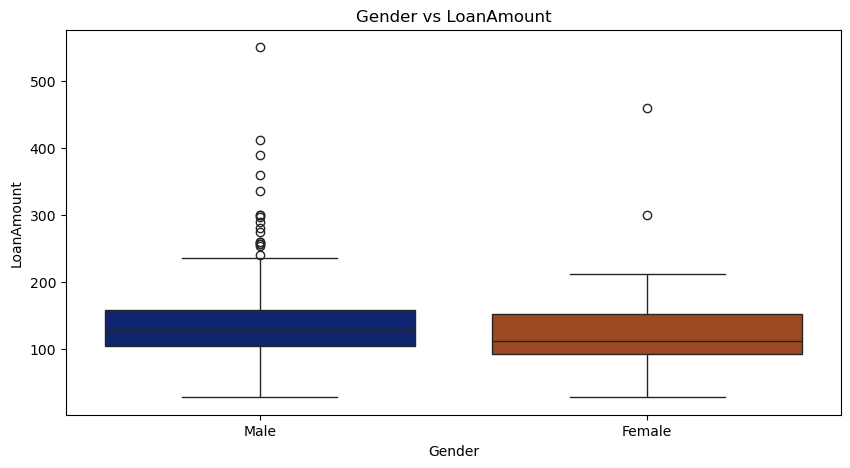

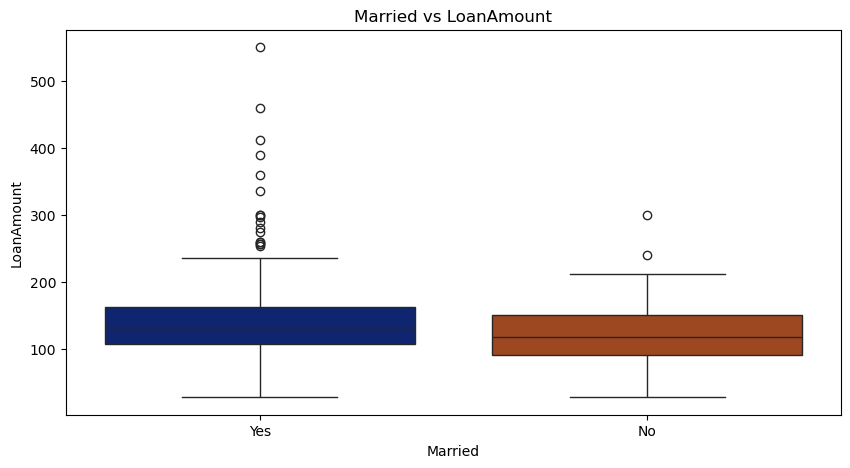

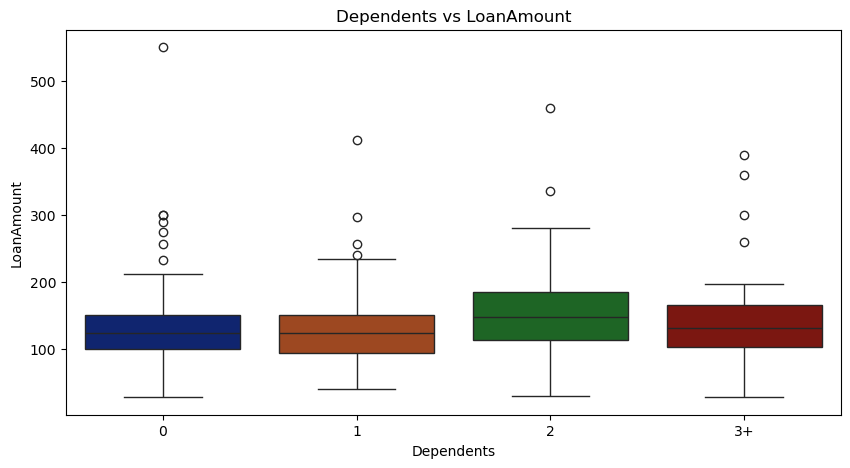

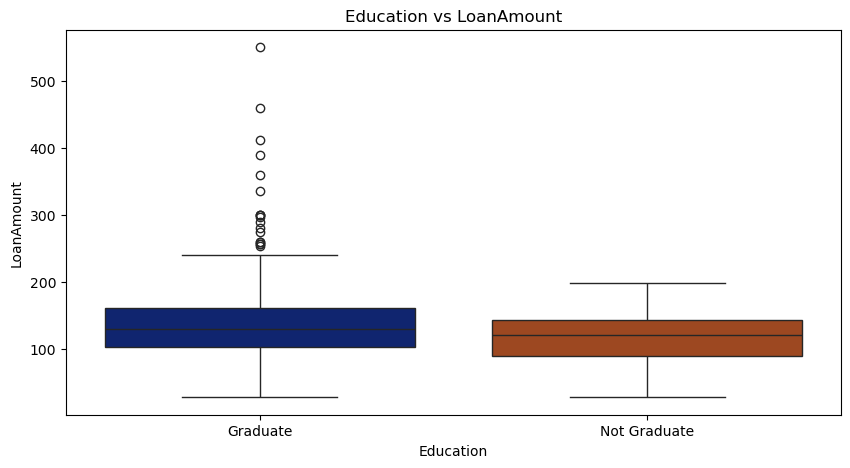

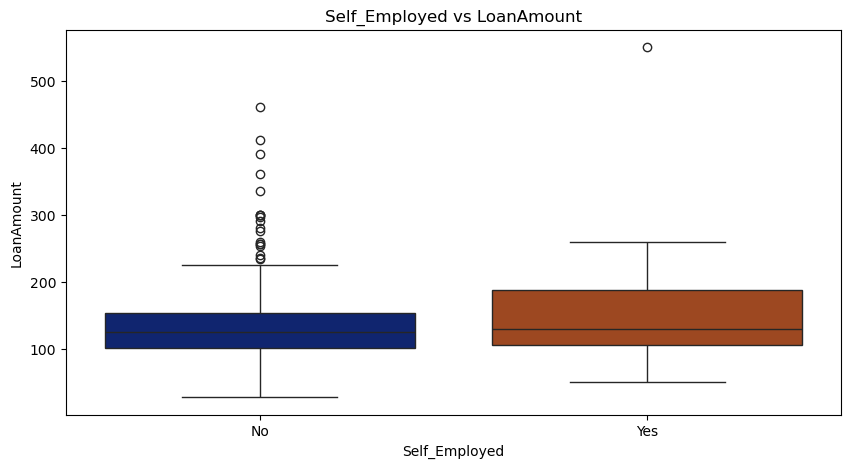

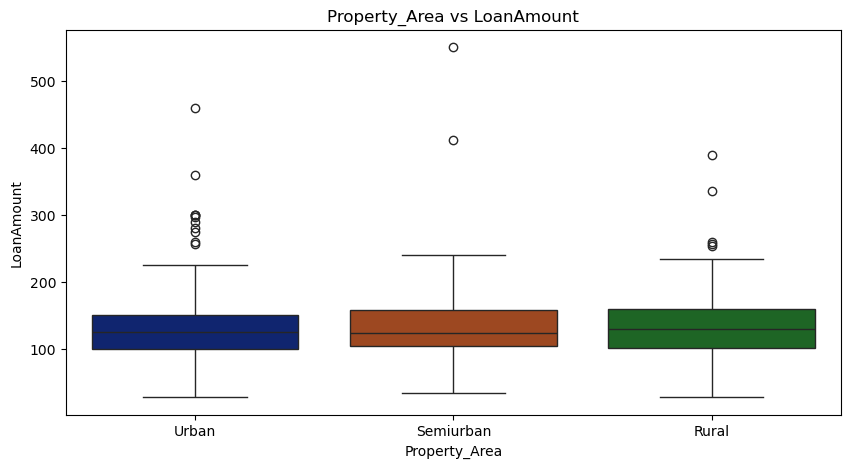

In [60]:
# Investigate the relationship between categorical and numeric variables using box plots or violin plots.
categorical_col = ['Loan_ID','Gender','Married','Dependents','Education','Self_Employed','Property_Area']

for col in categorical_col:
    plt.figure(figsize=(10,5))
    sns.boxplot(x=data[col], y=data['LoanAmount'], hue=data[col], palette='dark', legend=False)
    plt.title(f"{col} vs LoanAmount")
    plt.xlabel(col)
    plt.ylabel("LoanAmount")
    plt.show()

# 2.3 Multivariate Analysis

In [61]:
# Perform a correlation analysis to identify relationships between numeric variables
corr_matrix = data[numeric_cols].corr()
print(corr_matrix)

                   ApplicantIncome  CoapplicantIncome  LoanAmount  \
ApplicantIncome           1.000000          -0.110335    0.488737   
CoapplicantIncome        -0.110335           1.000000    0.150034   
LoanAmount                0.488737           0.150034    1.000000   
Loan_Amount_Term          0.023319          -0.008633    0.091867   
Credit_History            0.094944          -0.058004   -0.012932   

                   Loan_Amount_Term  Credit_History  
ApplicantIncome            0.023319        0.094944  
CoapplicantIncome         -0.008633       -0.058004  
LoanAmount                 0.091867       -0.012932  
Loan_Amount_Term           1.000000       -0.048189  
Credit_History            -0.048189        1.000000  


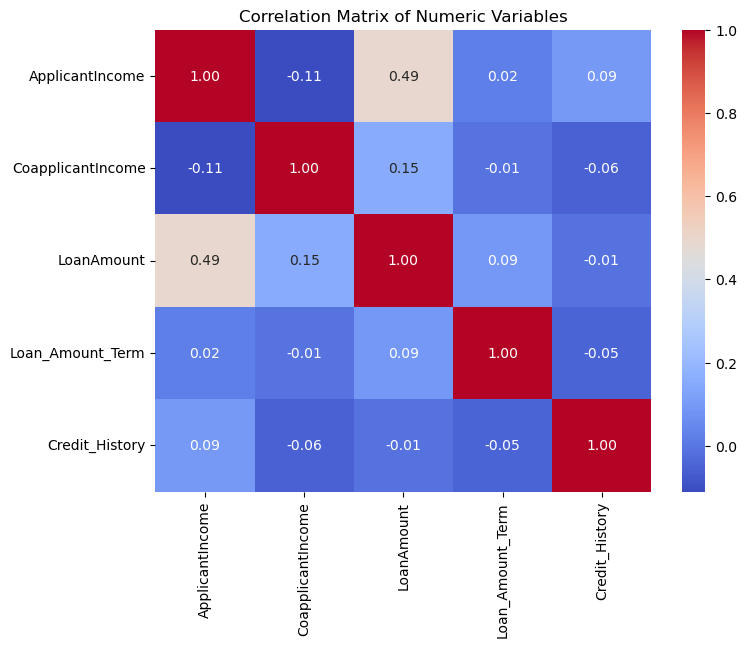

In [62]:
plt.figure(figsize=(8,6))
sns.heatmap(data[numeric_cols].corr(),annot=True,cmap='coolwarm',fmt=".2f")
plt.title("Correlation Matrix of Numeric Variables")
plt.show()

***Strong drivers: Applicant income and loan amount are positively correlated, while credit history stands out as a critical factor influencing loan approval.***

***Gender distribution: Males dominate loan applications across property areas, but females show presence in semiurban and urban regions—indicating emerging participation.***

***Strategic insight: Credit history is the most decisive numeric variable, while gender and property area highlight demographic trends in loan demand.***

***Takeaway: Credit history is the strongest predictor, while gender/property area patterns reveal market segments for outreach.***

In [65]:
data.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area'],
      dtype='object')

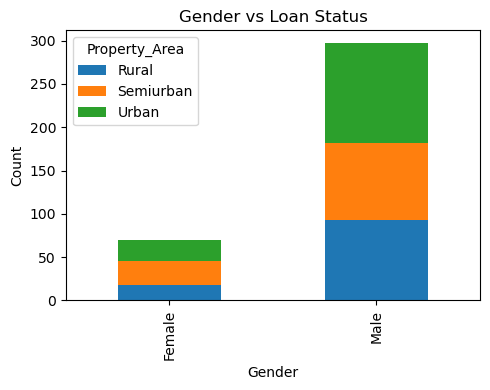

In [70]:
pd.crosstab(data['Gender'], data['Property_Area']).plot( kind='bar',stacked=True,figsize=(5,4))
plt.title("Gender vs Loan Status")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

***Applicant income and loan amount are positively linked.***

***Credit history is the strongest predictor of loan approval.***

***Male applicants dominate, but female presence is growing in semiurban/urban areas.***

***Credit history drives approvals; gender/property trends show market segments.***

# Task 3: Geospatial Analysis (Optional)

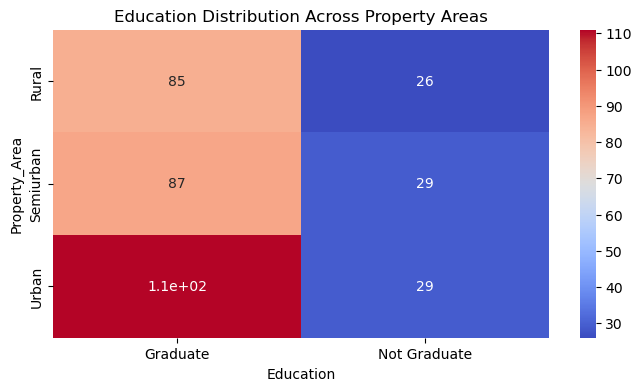

In [72]:
# dataset contains geographical information, visualize data on a map to identify regional trends
ct = pd.crosstab(data['Property_Area'],data['Education'])
plt.figure(figsize = (8,4))
sns.heatmap(ct , annot = True , cmap= 'coolwarm')
plt.title('Education Distribution Across Property Areas')
plt.show()

***Urban edge: Urban areas have the highest share of graduates, signaling stronger financial literacy and higher loan eligibility potential.***

***Semiurban balance: Semiurban regions show a moderate mix of graduates and non‑graduates, suggesting steady but uneven access to education.***

***Rural gap: Rural areas lag behind in graduate numbers, pointing to an educational disparity that could affect loan approvals.***

***Takeaway: Urban regions are education‑strong, semiurban areas balanced, and rural regions show gaps—valuable for tailoring loan strategies and outreach.***